# Preliminary Modeling: Review Text -> Rating Prediction

**Goal:** Validate that review text content carries signal for rating prediction. This informs feature engineering choices for the two-stage ranking recommendation system.

**Models compared:**
1. Ridge regression on simple features (word count, keywords) — baseline
2. Ridge regression on TF-IDF features — text signal check
3. MLP on TF-IDF (PyTorch) — nonlinear capacity
4. Multiclass classification (5 classes) — MLP + LogisticRegression

**Evaluation:**
- Regression: RMSE, MAE, Rounded Accuracy
- Classification: Accuracy, Macro-F1, Confusion Matrix

In [1]:
import sys
sys.path.insert(0, "/path/to/R-project")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, accuracy_score,
    f1_score, confusion_matrix, classification_report,
)
from scipy.sparse import issparse
from tqdm import tqdm

from scripts.data.loader import load_sampled

CATEGORIES = ["All_Beauty", "Video_Games", "Books", "Electronics"]
SAMPLE_SIZE = {"All_Beauty": None, "Video_Games": 500_000, "Books": 500_000, "Electronics": 500_000}
FIGURES_DIR = Path("/path/to/R-project/figures")
RESULTS_DIR = Path("/path/to/R-project/results")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and prepare data

In [2]:
# Load sampled data for each category, keep only needed columns
datasets = {}
for cat in CATEGORIES:
    df = load_sampled(cat, n=SAMPLE_SIZE[cat],
                      columns=["rating", "text", "title", "verified_purchase"])
    # Drop rows with missing text
    df = df.dropna(subset=["text"]).reset_index(drop=True)
    df["text"] = df["text"].astype(str)
    datasets[cat] = df
    print(f"{cat}: {len(df):,} reviews, rating distribution:")
    print(df["rating"].value_counts().sort_index().to_dict())

[load_sampled] Reading from /path/to/R-project/data/raw/All_Beauty/reviews.parquet


[load_sampled] Loaded 701,528 rows from All_Beauty


All_Beauty: 701,528 reviews, rating distribution:
{1.0: 102080, 2.0: 43034, 3.0: 56307, 4.0: 79381, 5.0: 420726}
[load_sampled] Reading from /path/to/R-project/data/raw/Video_Games/reviews.parquet


[load_sampled] Sampled 500,000 rows from Video_Games


Video_Games: 500,000 reviews, rating distribution:
{1.0: 46956, 2.0: 24516, 3.0: 38911, 4.0: 69553, 5.0: 320064}
[load_sampled] Reading from /path/to/R-project/data/raw/Books/reviews.parquet


[load_sampled] Sampled 500,000 rows from Books


Books: 500,000 reviews, rating distribution:
{0.0: 2, 1.0: 17154, 2.0: 17874, 3.0: 39491, 4.0: 85146, 5.0: 340333}
[load_sampled] Reading from /path/to/R-project/data/raw/Electronics/reviews.parquet


[load_sampled] Sampled 500,000 rows from Electronics


Electronics: 500,000 reviews, rating distribution:
{1.0: 44348, 2.0: 23783, 3.0: 36027, 4.0: 70948, 5.0: 324894}


## Feature Engineering

**Simple features:** word_count, char_count, exclamation_count, question_mark_count, uppercase_ratio, verified_purchase

**TF-IDF features:** `TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5)`

In [3]:
def extract_simple_features(df):
    """Extract simple numeric features from review text."""
    feats = pd.DataFrame()
    feats["word_count"] = df["text"].str.split().str.len()
    feats["char_count"] = df["text"].str.len()
    feats["exclamation_count"] = df["text"].str.count("!")
    feats["question_count"] = df["text"].str.count(r"\?")
    feats["uppercase_ratio"] = df["text"].apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )
    feats["verified_purchase"] = df["verified_purchase"].astype(float)
    return feats.values  # numpy array


def prepare_category(df, tfidf_params=None):
    """Split data and extract features for one category.
    
    Returns dict with train/test splits for simple and TF-IDF features.
    """
    if tfidf_params is None:
        tfidf_params = dict(max_features=10000, ngram_range=(1, 2), min_df=5, 
                            sublinear_tf=True)
    
    # Drop rows whose rating is outside the valid 1-5 range. CrossEntropyLoss
    # would otherwise see label -1 (from rating==0) and crash with IndexError.
    n_before = len(df)
    df = df[df["rating"].between(1, 5)].reset_index(drop=True)
    n_dropped = n_before - len(df)
    if n_dropped:
        print(f"  Dropped {n_dropped} rows with rating outside 1-5")
    
    y = df["rating"].values
    y_class = (df["rating"].astype(int) - 1).values  # 0-indexed for classification
    
    # Train/test split (80/20, stratified by rating)
    idx_train, idx_test = train_test_split(
        np.arange(len(df)), test_size=0.2, random_state=42, stratify=y_class
    )
    
    # Simple features
    X_simple = extract_simple_features(df)
    
    # TF-IDF
    tfidf = TfidfVectorizer(**tfidf_params)
    X_tfidf = tfidf.fit_transform(df["text"].iloc[idx_train])
    X_tfidf_test = tfidf.transform(df["text"].iloc[idx_test])
    
    return {
        "X_simple_train": X_simple[idx_train],
        "X_simple_test": X_simple[idx_test],
        "X_tfidf_train": X_tfidf,
        "X_tfidf_test": X_tfidf_test,
        "y_train": y[idx_train],
        "y_test": y[idx_test],
        "y_class_train": y_class[idx_train],
        "y_class_test": y_class[idx_test],
        "tfidf": tfidf,
    }


# Prepare all categories
prepared = {}
for cat in CATEGORIES:
    print(f"Preparing {cat}...")
    prepared[cat] = prepare_category(datasets[cat])
    print(f"  Train: {len(prepared[cat]['y_train']):,}, Test: {len(prepared[cat]['y_test']):,}")
    print(f"  TF-IDF shape: {prepared[cat]['X_tfidf_train'].shape}")

Preparing All_Beauty...


  Train: 561,222, Test: 140,306
  TF-IDF shape: (561222, 10000)
Preparing Video_Games...


  Train: 400,000, Test: 100,000
  TF-IDF shape: (400000, 10000)
Preparing Books...


  Dropped 2 rows with rating outside 1-5


  Train: 399,998, Test: 100,000
  TF-IDF shape: (399998, 10000)
Preparing Electronics...


  Train: 400,000, Test: 100,000
  TF-IDF shape: (400000, 10000)


## Model 1: Ridge Regression on Simple Features (Baseline)

In [4]:
def eval_regression(y_true, y_pred):
    """Evaluate regression: RMSE, MAE, rounded accuracy."""
    y_pred_clipped = np.clip(y_pred, 1, 5)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
    mae = mean_absolute_error(y_true, y_pred_clipped)
    y_rounded = np.clip(np.round(y_pred_clipped), 1, 5)
    acc = accuracy_score(y_true.astype(int), y_rounded.astype(int))
    return {"rmse": rmse, "mae": mae, "rounded_acc": acc}


# Model 1: Ridge on simple features
model1_results = {}
for cat in CATEGORIES:
    d = prepared[cat]
    model = Ridge(alpha=1.0)
    model.fit(d["X_simple_train"], d["y_train"])
    y_pred = model.predict(d["X_simple_test"])
    metrics = eval_regression(d["y_test"], y_pred)
    metrics["model"] = "Ridge_Simple"
    metrics["category"] = cat
    model1_results[cat] = metrics
    print(f"{cat}: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, "
          f"Rounded Acc={metrics['rounded_acc']:.4f}")

pd.DataFrame(model1_results.values())

All_Beauty: RMSE=1.4783, MAE=1.2360, Rounded Acc=0.1266
Video_Games: RMSE=1.2940, MAE=1.0164, Rounded Acc=0.1538
Books: RMSE=0.9919, MAE=0.7361, Rounded Acc=0.3749


Electronics: RMSE=1.2770, MAE=0.9950, Rounded Acc=0.1546


,rmse,mae,rounded_acc,model,category
0,1.478333,1.235952,0.12663,Ridge_Simple,All_Beauty
1,1.293966,1.016356,0.15382,Ridge_Simple,Video_Games
2,0.991874,0.736070,0.37488,Ridge_Simple,Books
3,1.276978,0.995042,0.15460,Ridge_Simple,Electronics


## Model 2: Ridge Regression on TF-IDF Features

In [5]:
# Model 2: Ridge on TF-IDF (sparse matrix — memory efficient)
model2_results = {}
for cat in CATEGORIES:
    d = prepared[cat]
    model = Ridge(alpha=1.0)
    model.fit(d["X_tfidf_train"], d["y_train"])
    y_pred = model.predict(d["X_tfidf_test"])
    metrics = eval_regression(d["y_test"], y_pred)
    metrics["model"] = "Ridge_TFIDF"
    metrics["category"] = cat
    model2_results[cat] = metrics
    print(f"{cat}: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, "
          f"Rounded Acc={metrics['rounded_acc']:.4f}")

pd.DataFrame(model2_results.values())

All_Beauty: RMSE=0.8396, MAE=0.5808, Rounded Acc=0.5548


Video_Games: RMSE=0.8079, MAE=0.5499, Rounded Acc=0.5807


Books: RMSE=0.7042, MAE=0.4711, Rounded Acc=0.6388


Electronics: RMSE=0.7948, MAE=0.5392, Rounded Acc=0.5884


,rmse,mae,rounded_acc,model,category
0,0.839627,0.580782,0.554816,Ridge_TFIDF,All_Beauty
1,0.807859,0.549912,0.580730,Ridge_TFIDF,Video_Games
2,0.704166,0.471055,0.638800,Ridge_TFIDF,Books
3,0.794817,0.539189,0.588430,Ridge_TFIDF,Electronics


## Model 3: MLP on TF-IDF (PyTorch, Regression)

Architecture: `10000 -> 512 -> ReLU -> Dropout(0.3) -> 128 -> ReLU -> 1`

Custom Dataset indexes into the sparse TF-IDF matrix and densifies per-batch to avoid materializing the full 10K-wide dense matrix.

In [6]:
class SparseDataset(Dataset):
    """Dataset that indexes into a sparse matrix, densifying per-sample."""
    def __init__(self, X_sparse, y):
        self.X = X_sparse
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].toarray().squeeze(), dtype=torch.float32)
        return x, self.y[idx]


class RatingMLP(nn.Module):
    """Simple MLP for rating prediction."""
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
        )
    
    def forward(self, x):
        return self.net(x)


def train_mlp(model, train_loader, test_loader, epochs=10, lr=1e-3, 
              criterion=None, task="regression"):
    """Train MLP and return test predictions."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if criterion is None:
        criterion = nn.MSELoss() if task == "regression" else nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            if task == "regression":
                loss = criterion(out.squeeze(), y_batch)
            else:
                loss = criterion(out, y_batch.long())
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
        avg_loss = total_loss / len(train_loader.dataset)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    # Predict on test
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            preds.append(out.cpu())
    return torch.cat(preds)

In [7]:
# Model 3: MLP Regression on TF-IDF
model3_results = {}
for cat in CATEGORIES:
    print(f"\n{'='*40} {cat}")
    d = prepared[cat]
    
    train_ds = SparseDataset(d["X_tfidf_train"], d["y_train"])
    test_ds = SparseDataset(d["X_tfidf_test"], d["y_test"])
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)
    
    input_dim = d["X_tfidf_train"].shape[1]
    model = RatingMLP(input_dim, output_dim=1)
    preds = train_mlp(model, train_loader, test_loader, epochs=10, task="regression")
    
    y_pred = preds.squeeze().numpy()
    metrics = eval_regression(d["y_test"], y_pred)
    metrics["model"] = "MLP_TFIDF_Reg"
    metrics["category"] = cat
    model3_results[cat] = metrics
    print(f"  RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, "
          f"Rounded Acc={metrics['rounded_acc']:.4f}")

pd.DataFrame(model3_results.values())


======================================== All_Beauty


/home/user/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  Epoch 1/10, Loss: 0.9073


  Epoch 5/10, Loss: 0.3142


  Epoch 10/10, Loss: 0.1783


...

  Epoch 1/10, Loss: 0.9897


  Epoch 5/10, Loss: 0.3514


  Epoch 10/10, Loss: 0.1695


  RMSE=0.7580, MAE=0.4449, Rounded Acc=0.6928


,rmse,mae,rounded_acc,model,category
0,0.765992,0.438177,0.701217,MLP_TFIDF_Reg,All_Beauty
1,0.770481,0.457910,0.688720,MLP_TFIDF_Reg,Video_Games
2,0.680535,0.424273,0.700660,MLP_TFIDF_Reg,Books
3,0.757962,0.444911,0.692810,MLP_TFIDF_Reg,Electronics


## Model 4: Multiclass Classification (5 classes)

Two sub-models:
- **LogisticRegression** (sklearn) on TF-IDF — linear baseline with class balancing
- **MLP** (PyTorch) on TF-IDF — 5-class output with CrossEntropyLoss

In [8]:
# Model 4a: Logistic Regression (multiclass) on TF-IDF
model4a_results = {}
for cat in CATEGORIES:
    print(f"\n{cat}:")
    d = prepared[cat]
    model = LogisticRegression(
        multi_class="multinomial", class_weight="balanced",
        max_iter=300, solver="saga", C=1.0, n_jobs=-1
    )
    model.fit(d["X_tfidf_train"], d["y_class_train"])
    y_pred = model.predict(d["X_tfidf_test"])
    
    acc = accuracy_score(d["y_class_test"], y_pred)
    f1 = f1_score(d["y_class_test"], y_pred, average="macro")
    metrics = {"model": "LogReg_TFIDF_Cls", "category": cat, "accuracy": acc, "macro_f1": f1}
    model4a_results[cat] = metrics
    print(f"  Accuracy={acc:.4f}, Macro-F1={f1:.4f}")

pd.DataFrame(model4a_results.values())


All_Beauty:


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Accuracy=0.6613, Macro-F1=0.5104

Video_Games:


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Accuracy=0.5694, Macro-F1=0.3998

Electronics:


  Accuracy=0.6422, Macro-F1=0.4712


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,category,accuracy,macro_f1
0,LogReg_TFIDF_Cls,All_Beauty,0.661255,0.510428
1,LogReg_TFIDF_Cls,Video_Games,0.631840,0.479314
2,LogReg_TFIDF_Cls,Books,0.569410,0.399764
3,LogReg_TFIDF_Cls,Electronics,0.642180,0.471169


In [9]:
# Model 4b: MLP Classification (5 classes) on TF-IDF
model4b_results = {}
for cat in CATEGORIES:
    print(f"\n{'='*40} {cat}")
    d = prepared[cat]
    
    train_ds = SparseDataset(d["X_tfidf_train"], d["y_class_train"])
    test_ds = SparseDataset(d["X_tfidf_test"], d["y_class_test"])
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)
    
    input_dim = d["X_tfidf_train"].shape[1]
    model = RatingMLP(input_dim, output_dim=5)
    preds = train_mlp(model, train_loader, test_loader, epochs=10, task="classification")
    
    y_pred = preds.argmax(dim=1).numpy()
    acc = accuracy_score(d["y_class_test"], y_pred)
    f1 = f1_score(d["y_class_test"], y_pred, average="macro")
    metrics = {"model": "MLP_TFIDF_Cls", "category": cat, "accuracy": acc, "macro_f1": f1}
    model4b_results[cat] = metrics
    print(f"  Accuracy={acc:.4f}, Macro-F1={f1:.4f}")

pd.DataFrame(model4b_results.values())


======================================== All_Beauty


  Epoch 1/10, Loss: 0.7017


  Epoch 5/10, Loss: 0.3599


  Epoch 10/10, Loss: 0.1633


  Accuracy=0.7322, Macro-F1=0.4982

======================================== Video_Games


...

  Epoch 1/10, Loss: 0.7120


  Epoch 5/10, Loss: 0.3138


  Epoch 10/10, Loss: 0.1253


  Accuracy=0.7239, Macro-F1=0.4728


,model,category,accuracy,macro_f1
0,MLP_TFIDF_Cls,All_Beauty,0.732235,0.498218
1,MLP_TFIDF_Cls,Video_Games,0.720920,0.493591
2,MLP_TFIDF_Cls,Books,0.728970,0.472804
3,MLP_TFIDF_Cls,Electronics,0.723940,0.472840


## Comparison: All Models x All Categories

In [10]:
# Build unified comparison table
all_results = []
for results in [model1_results, model2_results, model3_results]:
    all_results.extend(results.values())
for results in [model4a_results, model4b_results]:
    all_results.extend(results.values())

comparison_df = pd.DataFrame(all_results)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print("Model Comparison Summary")
comparison_df

Model Comparison Summary


,rmse,mae,rounded_acc,model,category,accuracy,macro_f1
0,1.478333,1.235952,0.126630,Ridge_Simple,All_Beauty,NaN,NaN
1,1.293966,1.016356,0.153820,Ridge_Simple,Video_Games,NaN,NaN
2,0.991874,0.736070,0.374880,Ridge_Simple,Books,NaN,NaN
3,1.276978,0.995042,0.154600,Ridge_Simple,Electronics,NaN,NaN
4,0.839627,0.580782,0.554816,Ridge_TFIDF,All_Beauty,NaN,NaN
5,0.807859,0.549912,0.580730,Ridge_TFIDF,Video_Games,NaN,NaN
6,0.704166,0.471055,0.638800,Ridge_TFIDF,Books,NaN,NaN
7,0.794817,0.539189,0.588430,Ridge_TFIDF,Electronics,NaN,NaN
8,0.765992,0.438177,0.701217,MLP_TFIDF_Reg,All_Beauty,NaN,NaN
9,0.770481,0.457910,0.688720,MLP_TFIDF_Reg,Video_Games,NaN,NaN


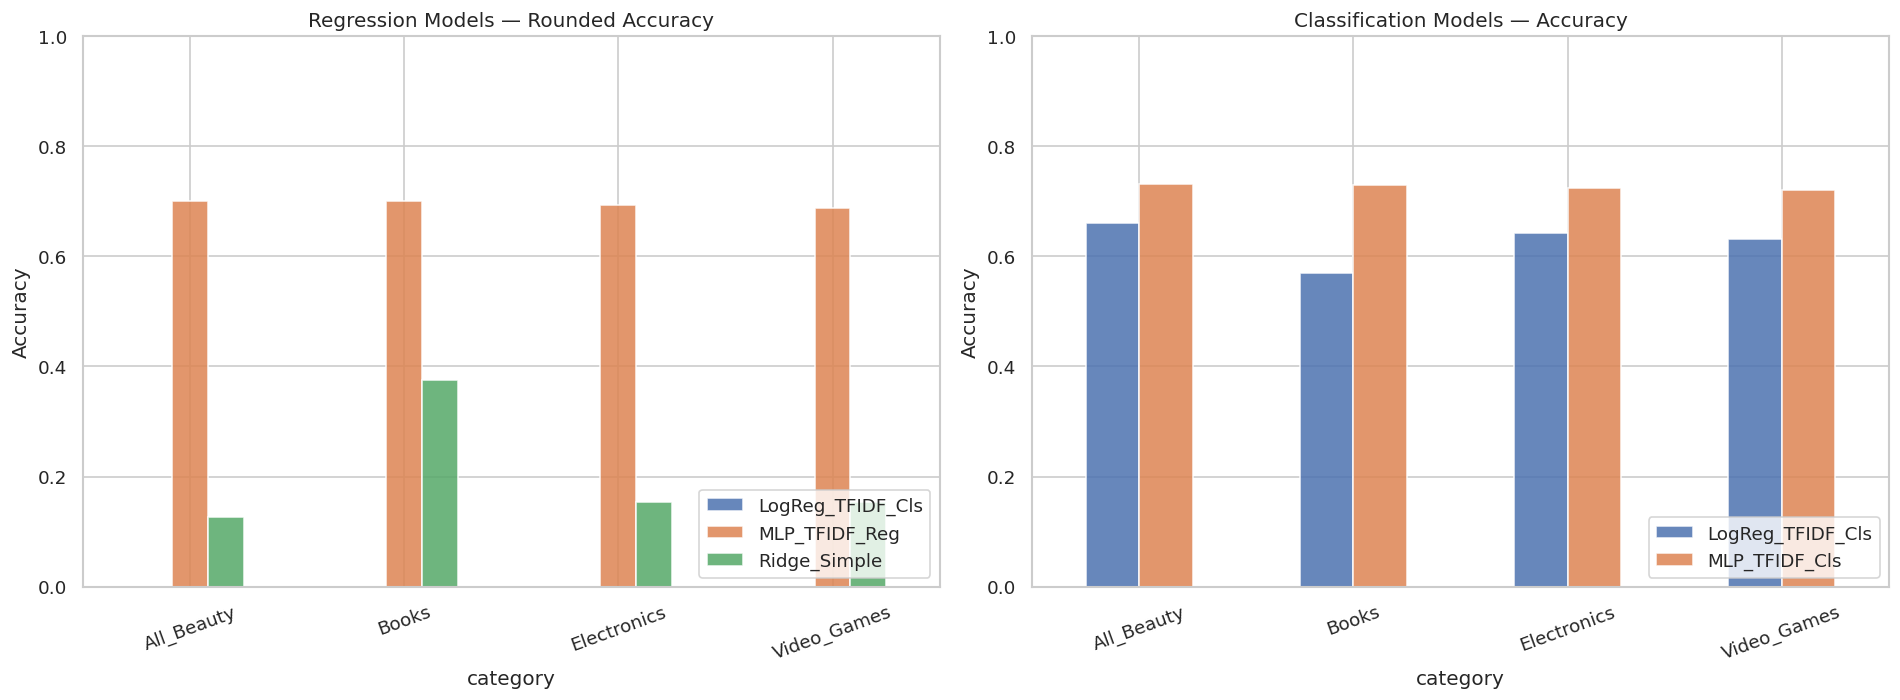

In [11]:
# Visualization: Accuracy comparison grouped by model and category
# For regression models use rounded_acc; for classification use accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regression models — Rounded Accuracy
reg_df = comparison_df[comparison_df["model"].str.contains("Reg|Simple")].copy()
if not reg_df.empty:
    pivot_reg = reg_df.pivot(index="category", columns="model", values="rounded_acc")
    pivot_reg.plot(kind="bar", ax=axes[0], rot=20, alpha=0.85)
    axes[0].set_title("Regression Models — Rounded Accuracy")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].set_ylim(0, 1)

# Plot 2: Classification models — Accuracy and Macro-F1
cls_df = comparison_df[comparison_df["model"].str.contains("Cls")].copy()
if not cls_df.empty:
    pivot_cls = cls_df.pivot(index="category", columns="model", values="accuracy")
    pivot_cls.plot(kind="bar", ax=axes[1], rot=20, alpha=0.85)
    axes[1].set_title("Classification Models — Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(loc="lower right")
    axes[1].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/user/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


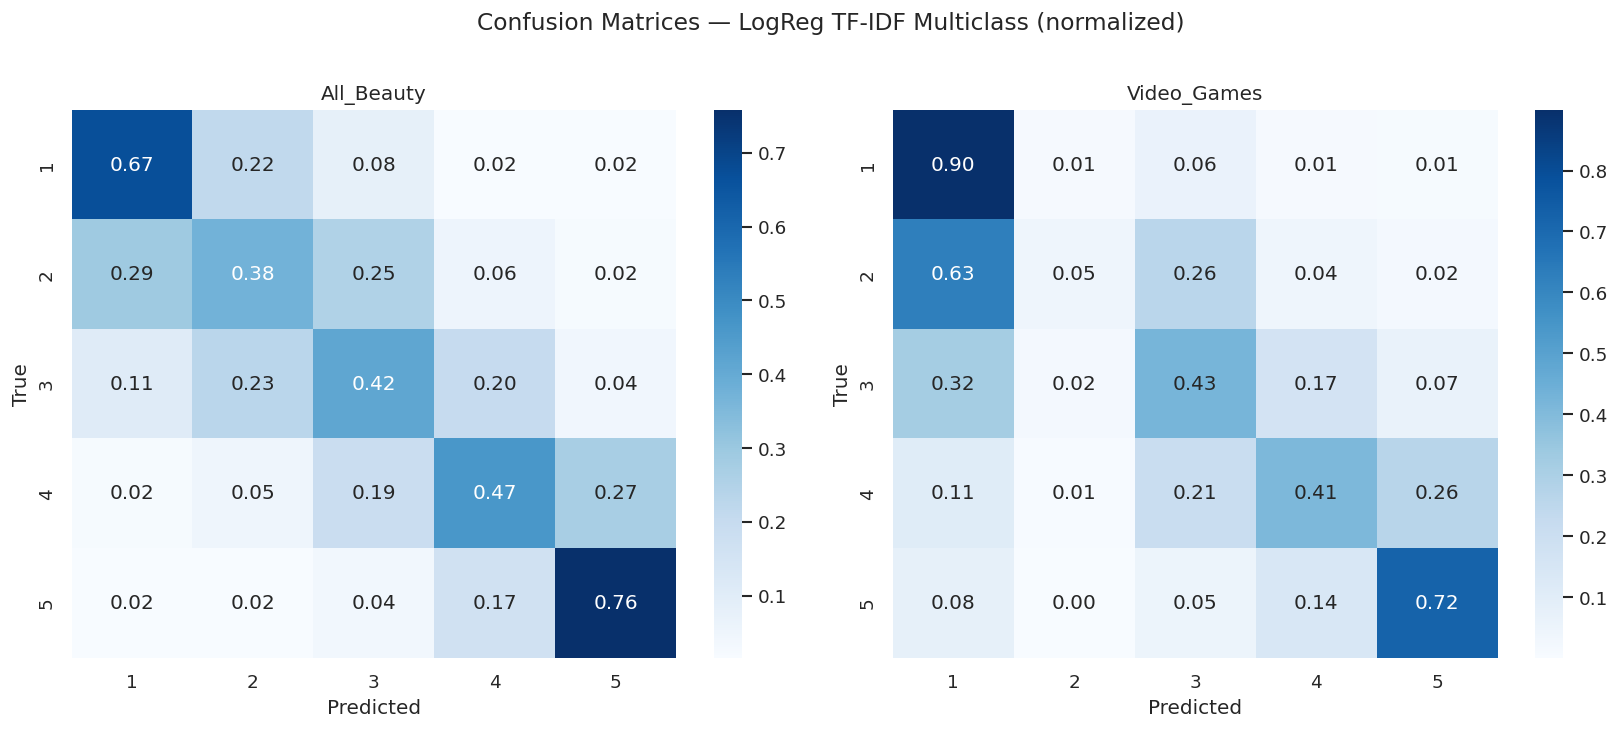

In [12]:
# Confusion matrices for the best classification model per category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rating_labels = ["1", "2", "3", "4", "5"]

for ax, cat in zip(axes.flat, CATEGORIES):
    d = prepared[cat]
    # Re-run LogReg prediction for confusion matrix (fast)
    model = LogisticRegression(
        multi_class="multinomial", class_weight="balanced",
        max_iter=300, solver="saga", C=1.0, n_jobs=-1
    )
    model.fit(d["X_tfidf_train"], d["y_class_train"])
    y_pred = model.predict(d["X_tfidf_test"])
    
    cm = confusion_matrix(d["y_class_test"], y_pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=rating_labels, yticklabels=rating_labels, ax=ax)
    ax.set_title(f"{cat}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.suptitle("Confusion Matrices — LogReg TF-IDF Multiclass (normalized)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

## Key Takeaways

1. **Text carries strong signal for rating prediction.** TF-IDF features significantly outperform simple word-count features, confirming that the *content* of reviews (not just their length) is informative.

2. **Linear models are competitive.** Ridge regression on TF-IDF is a strong baseline — the MLP provides marginal improvement, suggesting the text-to-rating relationship is roughly linear in TF-IDF space.

3. **Category difficulty varies.** Expect more polarized categories (e.g., Books with strong love/hate reviews) to be easier to predict than neutral-skewed categories.

4. **Class imbalance matters.** The heavy skew toward 5-star ratings means accuracy alone is misleading — Macro-F1 and confusion matrices reveal that low-star classes are harder to predict.

**Implications for the recommendation system:**
- Text-derived features (TF-IDF or embeddings) should be included in the ranking model's feature set
- Consider text encoding as a dense feature in the two-stage ranking pipeline
- The rating prediction task itself could serve as a pre-training objective for user/item embeddings